# Kilonovae

Kilonovae, the optical/near-infrared counterparts of neutron star mergers, are
fast-evolving, red transients whose spectra strongly depend on the angle from
which the merger is seen. `slicersim` models them with the POSSIS radiative
transfer models of [Bulla (2019)](https://arxiv.org/abs/1906.04205) and
Bulla (2023) (see `slicersim.scene.sources.kilonova`).

This notebook shows how to:
- create a Lazuli kilonova target (`LazuliKilonova`) and get its spectrum,
- change its properties: viewing angle, phase, redshift, brightness and model,
- compute exposure times,
- use the kilonova model directly, outside of any target.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import slicersim

***
## Create a kilonova target

`LazuliKilonova` works like `LazuliSupernova`: you give the source properties
and the scene (kilonova + zodiacal background) and the Lazuli instrument are set up
for you. Main parameters are:

| parameter | meaning | default |
|---|---|---|
| `model` | POSSIS model: `"bulla23"` or `"bulla19"` | `"bulla23"` |
| `redshift` | redshift of the kilonova | 0.2 |
| `phase` | days since the merger (observer-frame) | 1.4 |
| `theta` | viewing angle in degrees (0: pole-on, 90: edge-on) | 0 |
| `magabs` | peak absolute magnitude in `band` | -15.8 |
| `magobs` | peak observed magnitude in `band` (overrides `magabs`) | None |
| `band` | bandpass for the normalisation | `"sdssr"` |

*The first call downloads the model file, it is then cached.*

In [2]:
kilonova = slicersim.LazuliKilonova(redshift=0.05, phase=1.4, theta=30)

The kilonova parameters are mutable properties of the target:

In [3]:
kilonova.pointsource_properties

['pointsource.phase',
 'pointsource.redshift',
 'pointsource.theta',
 'pointsource.magobs',
 'pointsource.magabs',
 'pointsource.band',
 'pointsource.magsys',
 'pointsource.source',
 'pointsource.cosmo',
 'pointsource.position']

### Setup the instrument and get the spectrum

As for any target, you can set up the detector read-out to reach a given
signal-to-noise. Kilonovae are red, so let us ask for an average SNR of 10
per resolution element between 6000 and 9000 Å (observer-frame).

In [4]:
read_config, snr = kilonova.setup_to_snr(10, lbda_range=[6000, 9000], frame="obs")
kilonova.get_exposure_time() # in second

147.16

In [5]:
lbda, flux, variance = kilonova.get_spectrum(unit="flambda")
_, flux_nonoise, _ = kilonova.get_spectrum(unit="flambda", incl_error=False)

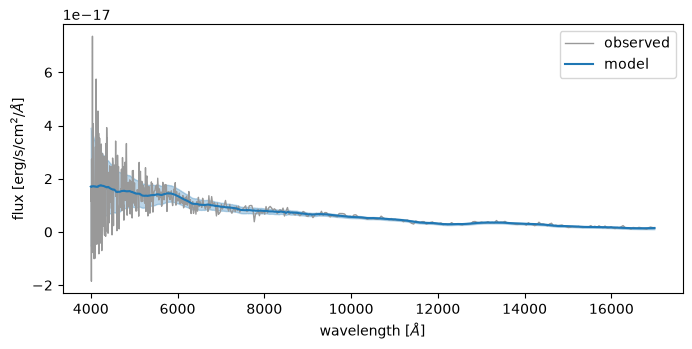

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.5))

ax.plot(lbda, flux, lw=1, color="0.6", label="observed")
ax.fill_between(lbda, flux_nonoise + np.sqrt(variance), flux_nonoise - np.sqrt(variance),
                color="C0", alpha=0.3)
ax.plot(lbda, flux_nonoise, lw=1.5, color="C0", label="model")
ax.set_xlabel(r"wavelength [$\AA$]")
ax.set_ylabel(r"flux [erg/s/cm$^2$/$\AA$]")
ax.legend()

***
## Change the kilonova properties

Use `change_properties()` to update the kilonova without rebuilding the target.

### Viewing angle

The viewing angle `theta` has a strong impact on the spectral shape: seen
edge-on (`theta=90`), the lanthanide-rich ejecta are in the line of sight
and the kilonova is redder.

*Note: the model is normalised to the same peak `magabs` (in `band`) for every
angle. This hence compares spectra at fixed peak brightness, not the intrinsic
brightness differences between viewing angles.*

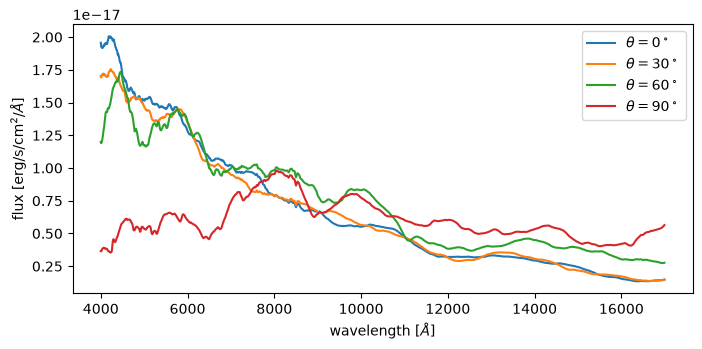

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.5))

for theta in [0, 30, 60, 90]:
    kilonova.change_properties(theta=theta)
    lbda, flux, _ = kilonova.get_spectrum(unit="flambda", incl_error=False)
    ax.plot(lbda, flux, lw=1.5, label=rf"$\theta={theta}^\circ$")

ax.set_xlabel(r"wavelength [$\AA$]")
ax.set_ylabel(r"flux [erg/s/cm$^2$/$\AA$]")
ax.legend()

kilonova.change_properties(theta=30) # back to the original angle

### Phase

Kilonovae evolve quickly: they fade and redden within days.

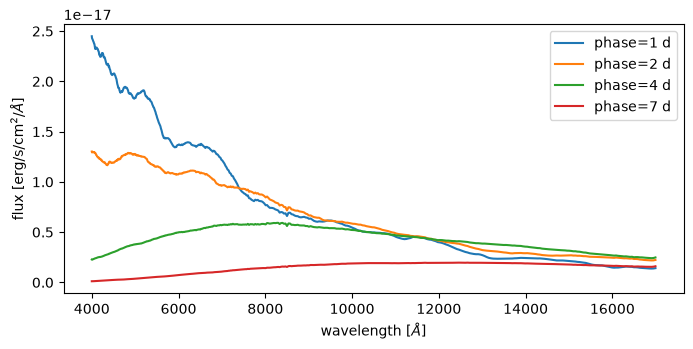

In [8]:
fig, ax = plt.subplots(figsize=(8, 3.5))

for phase in [1, 2, 4, 7]:
    kilonova.change_properties(phase=phase)
    lbda, flux, _ = kilonova.get_spectrum(unit="flambda", incl_error=False)
    ax.plot(lbda, flux, lw=1.5, label=f"phase={phase} d")

ax.set_xlabel(r"wavelength [$\AA$]")
ax.set_ylabel(r"flux [erg/s/cm$^2$/$\AA$]")
ax.legend()

kilonova.change_properties(phase=1.4) # back to the original phase

### Brightness

By default the kilonova is normalised to a peak absolute magnitude (`magabs`,
converted to an observed magnitude with the Planck18 cosmology). You can also
directly impose the peak observed magnitude with `magobs`, which then takes
precedence over `magabs`.

In [9]:
kn_mag22 = slicersim.LazuliKilonova(redshift=0.05, theta=30, magobs=22, band="sdssr")

### Model

Two POSSIS models are available, `"bulla23"` (default) and `"bulla19"`.

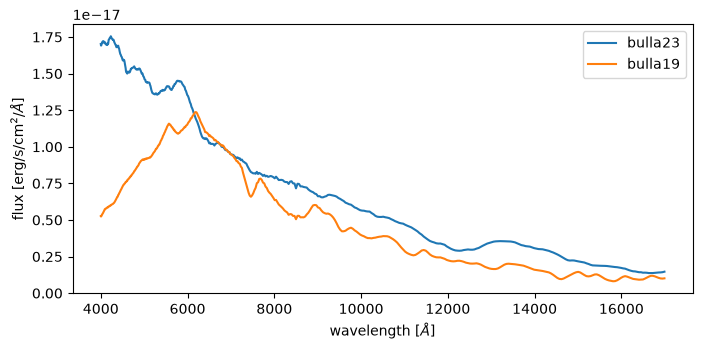

In [10]:
fig, ax = plt.subplots(figsize=(8, 3.5))

for model in ["bulla23", "bulla19"]:
    kn = slicersim.LazuliKilonova(model=model, redshift=0.05, theta=30)
    lbda, flux, _ = kn.get_spectrum(unit="flambda", incl_error=False)
    ax.plot(lbda, flux, lw=1.5, label=model)

ax.set_xlabel(r"wavelength [$\AA$]")
ax.set_ylabel(r"flux [erg/s/cm$^2$/$\AA$]")
ax.legend()

***
## Exposure time as a function of redshift

How long does it take to reach an average SNR of 10 between 6000 and 9000 Å
(observer-frame) for a kilonova observed 1.4 days after the merger, as a
function of its redshift?

*each `setup_to_snr()` takes a few seconds.*

In [11]:
redshifts = [0.02, 0.05, 0.1, 0.15]
exposure_times = []
for redshift in redshifts:
    kilonova.change_properties(redshift=redshift)
    _ = kilonova.setup_to_snr(10, lbda_range=[6000, 9000], frame="obs")
    exposure_times.append(kilonova.get_exposure_time())

Text(0.5, 1.0, 'SNR=10 in [6000, 9000] (obs), phase=1.4 d')

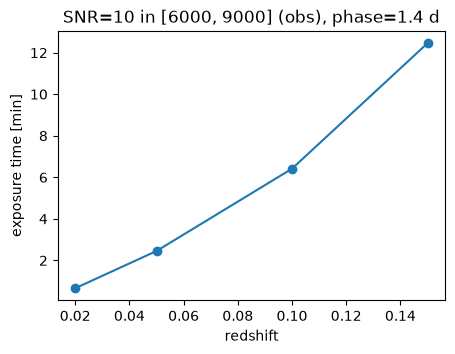

In [12]:
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(redshifts, np.asarray(exposure_times) / 60, marker="o")
ax.set_xlabel("redshift")
ax.set_ylabel("exposure time [min]")
ax.set_title("SNR=10 in [6000, 9000] (obs), phase=1.4 d")

***
## Use the kilonova model directly

The spectral model used by `LazuliKilonova` is
`slicersim.scene.sources.kilonova.get_kilonova_flux`. You can use it
directly to get the input (noise-free, instrument-free) spectrum in erg/s/cm²/Å.

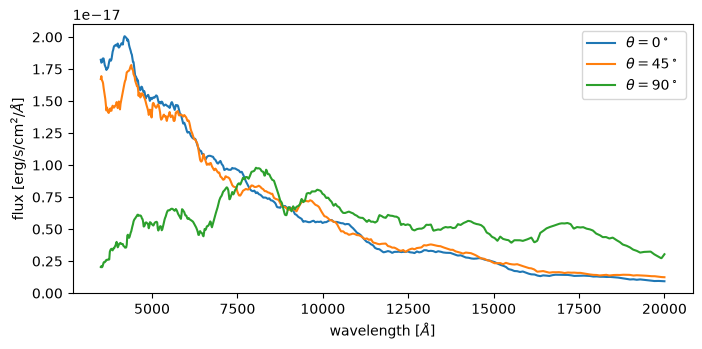

In [13]:
from slicersim.scene.sources.kilonova import get_kilonova_flux

lbda = np.linspace(3_500, 20_000, 1000)
fig, ax = plt.subplots(figsize=(8, 3.5))
for theta in [0, 45, 90]:
    flux = get_kilonova_flux(lbda, phase=1.4, redshift=0.05, theta=theta, source="bulla23")
    ax.plot(lbda, flux, label=rf"$\theta={theta}^\circ$")

ax.set_xlabel(r"wavelength [$\AA$]")
ax.set_ylabel(r"flux [erg/s/cm$^2$/$\AA$]")
ax.legend()

The underlying `sncosmo.Model` is also available, e.g. to compute light curves:

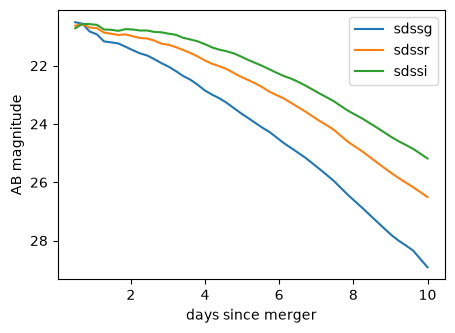

In [14]:
from slicersim.scene.sources.kilonova import get_kilonova_model, bulla23_url

model = get_kilonova_model(bulla23_url)
model.set(z=0.05, theta=30)
model.set_source_peakabsmag(-15.8, "sdssr", "ab")

phases = np.linspace(0.5, 10, 50)
fig, ax = plt.subplots(figsize=(5, 3.5))
for band in ["sdssg", "sdssr", "sdssi"]:
    ax.plot(phases, model.bandmag(band, "ab", phases), label=band)

ax.invert_yaxis()
ax.set_xlabel("days since merger")
ax.set_ylabel("AB magnitude")
ax.legend()

Finally, a kilonova scene configuration, e.g. to build your own `Simulation`, is
obtained with `slicersim.scene.get_scene`, using `"kilonova-{model}"` as source:

In [15]:
from slicersim.scene import get_scene
get_scene("kilonova-bulla19", redshift=0.05, theta=30)

{'scene': {'pointsource': {'name': 'kilonova',
   'redshift': 0.05,
   'phase': 1.4,
   'position': [1, 0.5],
   'source': 'bulla19',
   'theta': 30},
  'background': {'name': 'zodi', 'model': 'Aldering01.BB5800', 'scale': 2.0},
  'host': {}}}